In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [3]:
df=pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.shape

(6435, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [9]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [13]:
cat_cols=df.dtypes[df.dtypes=="object"].index
cat_cols

Index(['Date'], dtype='object')

In [15]:
num_cols=df.dtypes[df.dtypes!="object"].index
num_cols

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI', 'Unemployment'],
      dtype='object')

## Univariate Analysis
1. Weekly_Sales column has outliers
2. Temperature column has outliers
3. Unemployment column has outliers

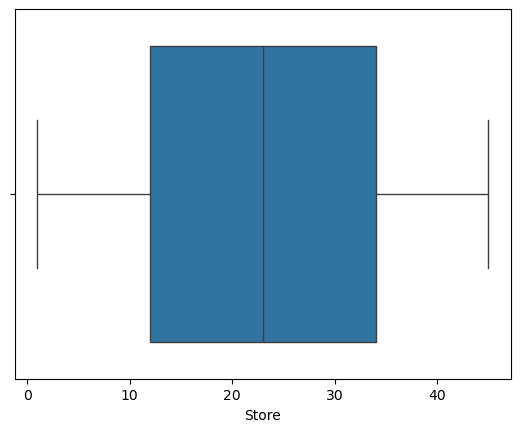

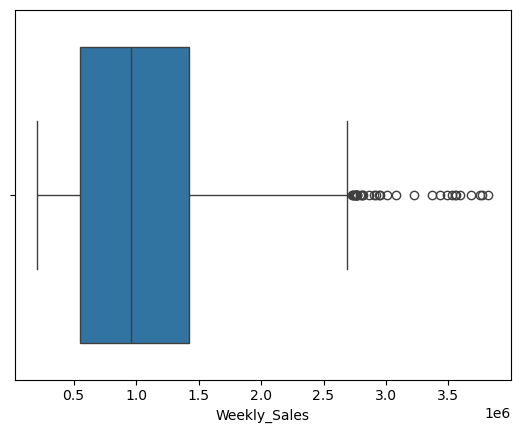

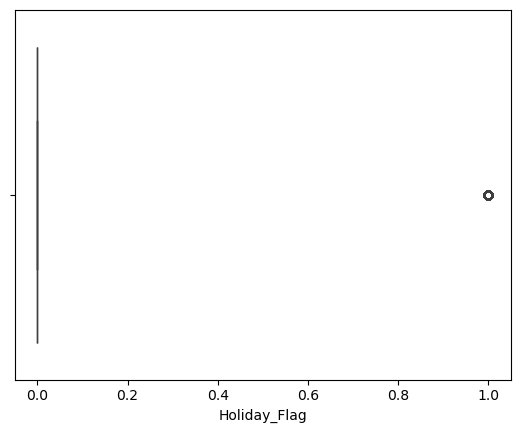

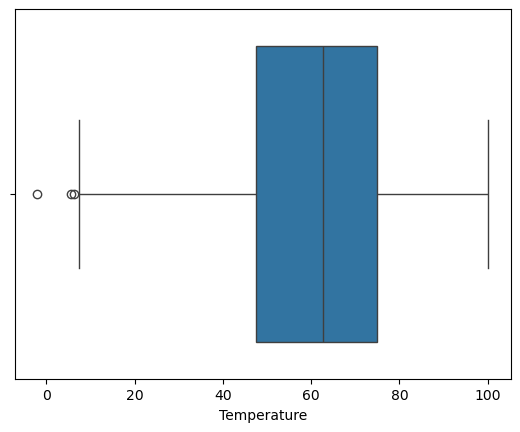

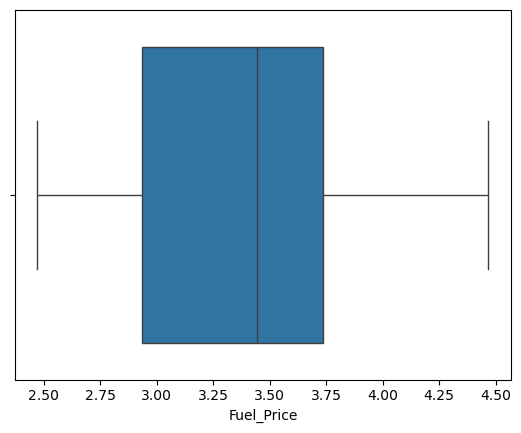

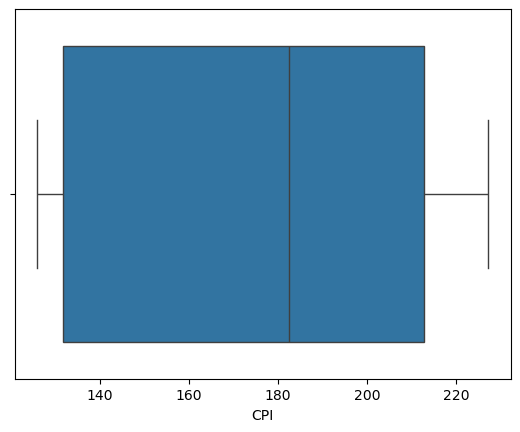

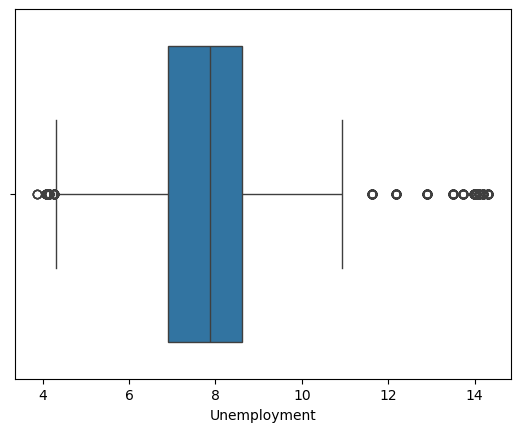

In [18]:
for i in num_cols:
    sns.boxplot(x=df[i])
    plt.show()

In [19]:
df.drop(columns=["Date"],inplace=True)

In [22]:
from sklearn.preprocessing import Normalizer
normalizer = Normalizer(norm='max') 
df_normalized = pd.DataFrame(normalizer.fit_transform(df), columns=df.columns)

In [24]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,1554806.68,0,46.50,2.625,211.350143,8.106


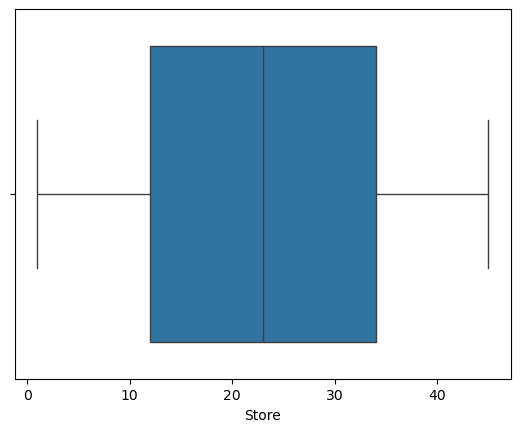

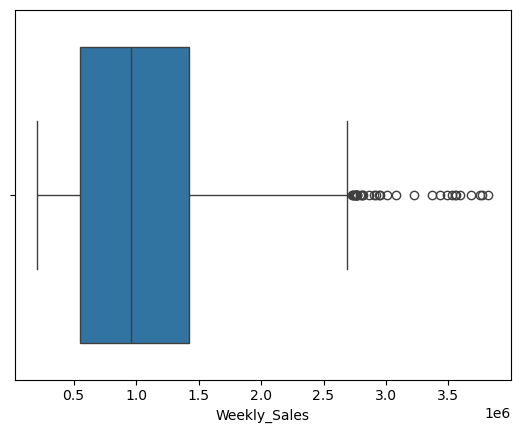

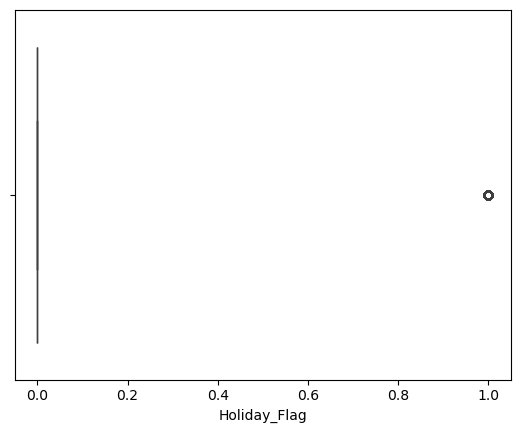

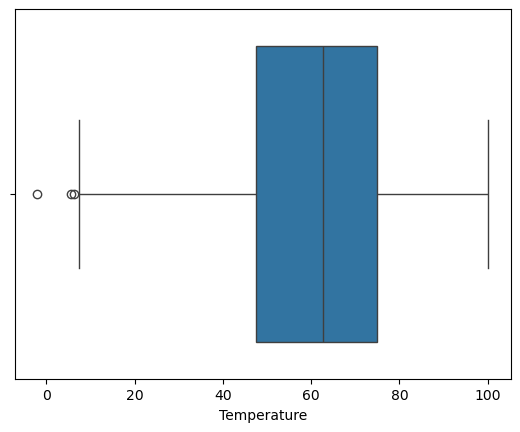

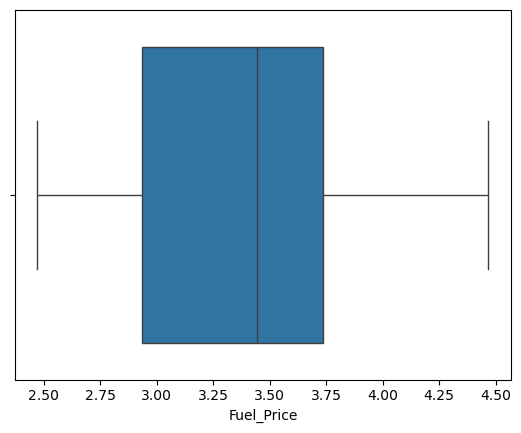

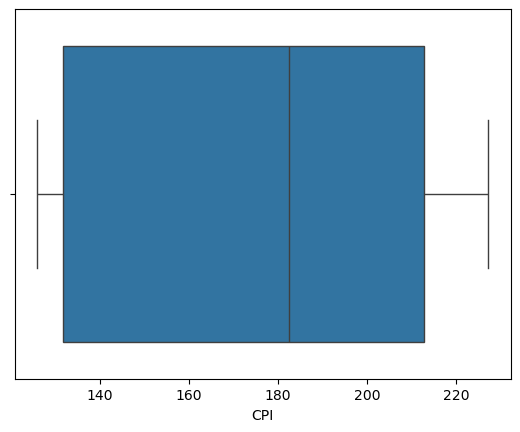

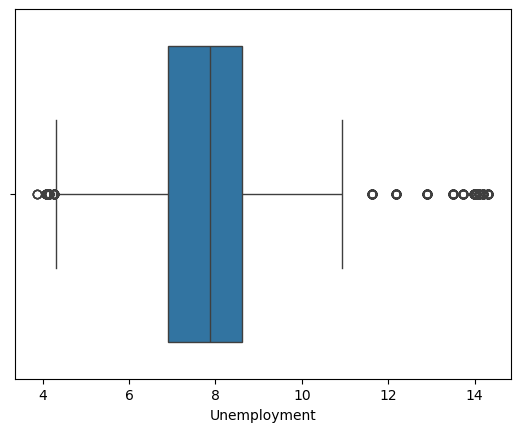

In [26]:
for i in num_cols:
    sns.boxplot(x=df[i])
    plt.show()

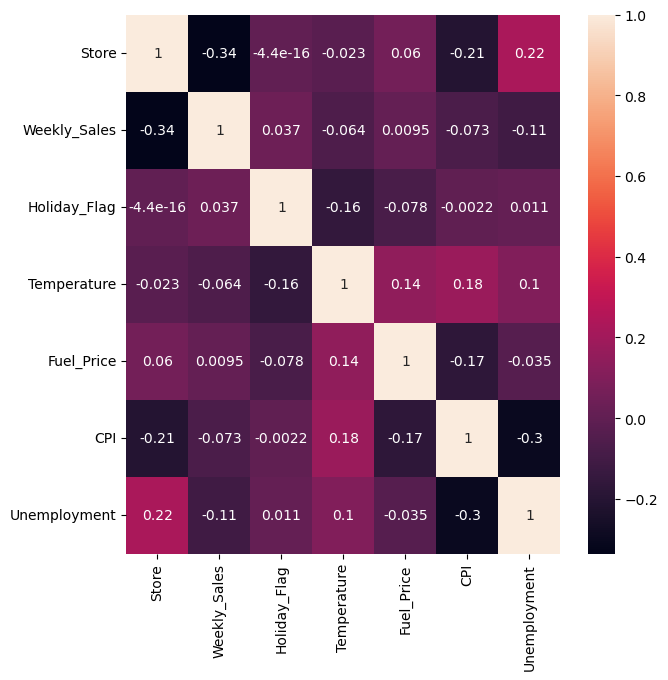

In [28]:
corr=df.corr()
plt.figure(figsize=(7,7))
sns.heatmap(corr,annot=True)
plt.rc('ytick', labelsize=8)
plt.show()

In [30]:
x=df.drop("Weekly_Sales",axis=1)
y=df["Weekly_Sales"]
print(x.shape)
print(y.shape)

(6435, 6)
(6435,)


In [32]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,
                                                random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4826, 6)
(1609, 6)
(4826,)
(1609,)


In [34]:
m1 = LinearRegression()
m1.fit(x_train,y_train)

LinearRegression()

In [36]:
# Model score - R2_Score
print('Training Score',m1.score(x_train,y_train))
print('Testing Score',m1.score(x_test,y_test))

Training Score 0.13957159886693704
Testing Score 0.14530097512188278


In [44]:
import statsmodels.api as sm

# Add constant to x_train
X = sm.add_constant(x_train)  # Adds a bias term C

# Fit the OLS model
m2 = sm.OLS(y_train, X).fit()  # Corrected order

# Summary of the model
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     130.3
Date:                Thu, 13 Feb 2025   Prob (F-statistic):          2.82e-153
Time:                        10:05:20   Log-Likelihood:                -70391.
No. Observations:                4826   AIC:                         1.408e+05
Df Residuals:                    4819   BIC:                         1.408e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2.052e+06   8.72e+04     23.538   